# PROYECTO FINAL – ANÁLISIS, LIMPIEZA Y VISUALIZACIÓN DE DATOS
## Dataset: Crime Data from 2020 to 2024

Autor: Alejandro Cabrera Barea <br>
Curso: Desarrollo de Aplicaciones en Lenguaje Python <br>
Centro: IES Zaidín-Vergeles

---

# FASE DE DISEÑO Y ORIGEN DE DATOS

## 1. Descripción del Dataset

El dataset utilizado contiene información sobre crímenes registrados en Estados Unidos desde el año 2020 hasta 2024.

Fuente de datos: CSV descargado desde repositorios públicos de datos.

Este conjunto de datos resulta interesante porque permite:

- Analizar tendencias criminales a lo largo del tiempo.
- Detectar patrones geográficos y temporales.
- Estudiar la relación entre diferentes tipos de delitos.
- Obtener conclusiones útiles mediante visualizaciones.

---

## 2. Diccionario de Variables

| Variable | Descripción | Tipo |
|---|---|---|
| DR_NO | Número de reporte | Numérico |
| Date Rptd | Fecha del reporte | Fecha |
| DATE OCC | Fecha del crimen | Fecha |
| TIME OCC | Hora del crimen | Numérico |
| AREA NAME | Zona | Categórica |
| Crm Cd Desc | Descripción del crimen | Categórica |
| Vict Age | Edad de la víctima | Numérico |
| Vict Sex | Sexo de la víctima | Categórica |
| Vict Descent | Descendencia de la víctima | Categórica |
| Premis Desc | Lugar del crimen | Categórica |
| Weapon Desc | Arma utilizada | Categórica |
| Status Desc | Estado del caso | Categórica |
| LAT | Latitud | Numérico |
| LON | Longitud | Numérico |

---

## 3. Hipótesis de Análisis

1. ¿Qué tipos de crímenes son los más frecuentes?
2. ¿Existen zonas con mayor criminalidad?
3. ¿Hay relación entre la edad de las víctimas y ciertos tipos de delitos?
4. ¿Qué franjas horarias concentran más delitos?
5. ¿Existen correlaciones importantes entre variables numéricas?

---

# FASE DE IMPLEMENTACIÓN – JUPYTER NOTEBOOK

# ==============================================
# BLOQUE 0 - IMPORTACIÓN DE LIBRERÍAS
# ==============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

---

# ==============================================
# BLOQUE 1 - INGESTA Y CALIDAD (RA1)
# ==============================================

## 1. Carga del Dataset

In [3]:
# Ruta del archivo CSV
ruta = '../Files/Crime_Data_from_2020_to_2024.csv'

# Cargar dataset
crime_df = pd.read_csv(ruta)

# Mostrar primeras filas
crime_df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


## 2. Información General del Dataset

In [4]:
print('DIMENSIONES DEL DATASET')
print(crime_df.shape)

print('\nINFORMACIÓN GENERAL')
crime_df.info()

DIMENSIONES DEL DATASET
(1004894, 28)

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  str    
 2   DATE OCC        1004894 non-null  str    
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  str    
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  str    
 10  Mocodes         853296 non-null   str    
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   str    
 13  Vict Descent    860251 non-null   str    
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  s

## 3. Estadísticas Descriptivas

In [5]:
crime_df.describe(include='all')

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
count,1.004894e+06,1004894,1004894,1.004894e+06,1.004894e+06,1004894,1.004894e+06,1.004894e+06,1.004894e+06,1004894,853296,1.004894e+06,860263,860251,1.004878e+06,1004306,327216.000000,327216,1004893,1004894,1.004883e+06,69154.000000,2314.000000,64.00000,1004894,154228,1.004894e+06,1.004894e+06
unique,NaN,1870,1826,NaN,NaN,21,NaN,NaN,NaN,140,310912,NaN,5,20,NaN,306,NaN,79,6,6,NaN,NaN,NaN,NaN,66566,10413,NaN,NaN
top,NaN,02/02/2023 12:00:00 AM,01/01/2020 12:00:00 AM,NaN,NaN,Central,NaN,NaN,NaN,VEHICLE - STOLEN,0344,NaN,M,H,NaN,STREET,NaN,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,NaN,NaN,NaN,NaN,800 N ALAMEDA ST,BROADWAY,NaN,NaN
freq,NaN,929,1164,NaN,NaN,69668,NaN,NaN,NaN,115184,42185,NaN,403842,296370,NaN,261261,NaN,174739,802772,802772,NaN,NaN,NaN,NaN,2598,2486,NaN,NaN
mean,2.202190e+08,NaN,NaN,1.339901e+03,1.069153e+01,NaN,1.115613e+03,1.400313e+00,5.001386e+02,NaN,NaN,2.891862e+01,NaN,NaN,3.056108e+02,NaN,363.950797,NaN,NaN,NaN,4.998992e+02,958.097796,984.015990,991.21875,NaN,NaN,3.399820e+01,-1.180908e+02
std,1.319070e+07,NaN,NaN,6.510761e+02,6.110248e+00,NaN,6.111596e+02,4.899620e-01,2.052638e+02,NaN,NaN,2.199267e+01,NaN,NaN,2.192913e+02,NaN,123.737665,NaN,NaN,NaN,2.050643e+02,110.358509,52.350982,27.06985,NaN,NaN,1.610789e+00,5.582654e+00
min,8.170000e+02,NaN,NaN,1.000000e+00,1.000000e+00,NaN,1.010000e+02,1.000000e+00,1.100000e+02,NaN,NaN,-4.000000e+00,NaN,NaN,1.010000e+02,NaN,101.000000,NaN,NaN,NaN,1.100000e+02,210.000000,310.000000,821.00000,NaN,NaN,0.000000e+00,-1.186676e+02
25%,2.106168e+08,NaN,NaN,9.000000e+02,5.000000e+00,NaN,5.870000e+02,1.000000e+00,3.310000e+02,NaN,NaN,0.000000e+00,NaN,NaN,1.010000e+02,NaN,311.000000,NaN,NaN,NaN,3.310000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.401470e+01,-1.184305e+02
50%,2.209158e+08,NaN,NaN,1.420000e+03,1.100000e+01,NaN,1.139000e+03,1.000000e+00,4.420000e+02,NaN,NaN,3.000000e+01,NaN,NaN,2.030000e+02,NaN,400.000000,NaN,NaN,NaN,4.420000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.405890e+01,-1.183225e+02
75%,2.311102e+08,NaN,NaN,1.900000e+03,1.600000e+01,NaN,1.613000e+03,2.000000e+00,6.260000e+02,NaN,NaN,4.400000e+01,NaN,NaN,5.010000e+02,NaN,400.000000,NaN,NaN,NaN,6.260000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.416490e+01,-1.182739e+02


## 4. Verificación de Valores Nulos

In [6]:
nulos = crime_df.isnull().sum()

nulos = nulos[nulos > 0].sort_values(ascending=False)

print(nulos)

Crm Cd 4          1004830
Crm Cd 3          1002580
Crm Cd 2           935740
Cross Street       850666
Weapon Desc        677678
Weapon Used Cd     677678
Mocodes            151598
Vict Descent       144643
Vict Sex           144631
Premis Desc           588
Premis Cd              16
Crm Cd 1               11
Status                  1
dtype: int64


## 5. Exportación de un Subconjunto

In [8]:
# Seleccionar columnas importantes
subset_df = crime_df[[
    'DATE OCC',
    'AREA NAME',
    'Crm Cd Desc',
    'Vict Age',
    'Vict Sex'
]].copy()

# Exportar a Excel
subset_df.to_excel('../Files/subset_crime_data.xlsx', index=False)

# Exportar a JSON
subset_df.to_json('../Files/subset_crime_data.json', orient='records')

print('Archivos exportados correctamente')

Archivos exportados correctamente


# ==============================================
# BLOQUE 2 - LIMPIEZA Y ESTANDARIZACIÓN (RA2)
# ==============================================

## 1. Copia de Seguridad del Dataset

In [9]:
clean_df = crime_df.copy()

## 2. Conversión de Fechas

In [10]:
clean_df['Date Rptd'] = pd.to_datetime(clean_df['Date Rptd'], errors='coerce')
clean_df['DATE OCC'] = pd.to_datetime(clean_df['DATE OCC'], errors='coerce')

## 3. Tratamiento de Valores Nulos

In [11]:
# Revisar porcentaje de nulos
porcentaje_nulos = (clean_df.isnull().sum() / len(clean_df)) * 100

porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)

print(porcentaje_nulos)

Crm Cd 4          99.993631
Crm Cd 3          99.769727
Crm Cd 2          93.118279
Cross Street      84.652312
Weapon Used Cd    67.437760
Weapon Desc       67.437760
Mocodes           15.085969
Vict Descent      14.393856
Vict Sex          14.392662
Premis Desc        0.058514
Premis Cd          0.001592
Crm Cd 1           0.001095
Status             0.000100
Vict Age           0.000000
Crm Cd             0.000000
Crm Cd Desc        0.000000
AREA NAME          0.000000
Rpt Dist No        0.000000
AREA               0.000000
TIME OCC           0.000000
Date Rptd          0.000000
DATE OCC           0.000000
DR_NO              0.000000
Part 1-2           0.000000
Status Desc        0.000000
LOCATION           0.000000
LAT                0.000000
LON                0.000000
dtype: float64


In [12]:
# Rellenar edades nulas con mediana
clean_df['Vict Age'] = clean_df['Vict Age'].fillna(clean_df['Vict Age'].median())

# Rellenar variables categóricas con 'Unknown'
columnas_categoricas = [
    'Vict Sex',
    'Vict Descent',
    'Weapon Desc',
    'Premis Desc'
]

for col in columnas_categoricas:
    clean_df[col] = clean_df[col].fillna('Unknown')

## 4. Eliminación de Duplicados

In [13]:
duplicados = clean_df.duplicated().sum()

print(f'Duplicados encontrados: {duplicados}')

clean_df.drop_duplicates(inplace=True)

Duplicados encontrados: 0


## 5. Tratamiento de Outliers

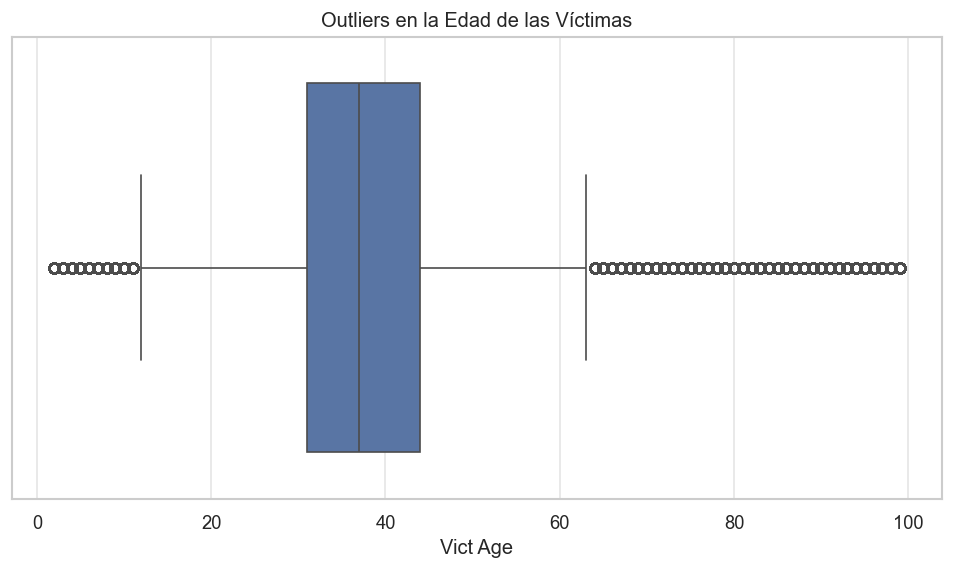

In [38]:
# Visualizar outliers de edad
plt.figure(figsize=(10,5))

sns.boxplot(x=clean_df['Vict Age'])

plt.title('Outliers en la Edad de las Víctimas')

plt.savefig('../Jupyter/boxplot_outliers_edad.png')

plt.show()

# Reemplazar edades irreales por NaN
clean_df['Vict Age'] = clean_df['Vict Age'].replace(0, np.nan)
clean_df.loc[
    (clean_df['Vict Age'] < 0) | (clean_df['Vict Age'] > 100),
    'Vict Age'
] = np.nan

# Eliminar filas con edades nulas
clean_df = clean_df.dropna(subset=['Vict Age'])

In [39]:
# Eliminar edades irreales
clean_df = clean_df[(clean_df['Vict Age'] >= 0) & (clean_df['Vict Age'] <= 100)]

## 6. Creación de Nuevas Variables

In [40]:
# Año del crimen
clean_df['YEAR_OCC'] = clean_df['DATE OCC'].dt.year

# Mes del crimen
clean_df['MONTH_OCC'] = clean_df['DATE OCC'].dt.month

# Hora simplificada
clean_df['HOUR_OCC'] = clean_df['TIME OCC'] // 100

## 7. Codificación de Variables Categóricas

In [41]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columnas_encode = [
    'Vict Sex',
    'AREA NAME',
    'Status Desc'
]

for col in columnas_encode:
    clean_df[col + '_ENCODED'] = encoder.fit_transform(clean_df[col].astype(str))

# ==============================================
# BLOQUE 3 - ANÁLISIS EXPLORATORIO (RA3)
# ==============================================

# ==============================================
# 1. ANÁLISIS DE TENDENCIAS
# ==============================================

## Crímenes Más Frecuentes

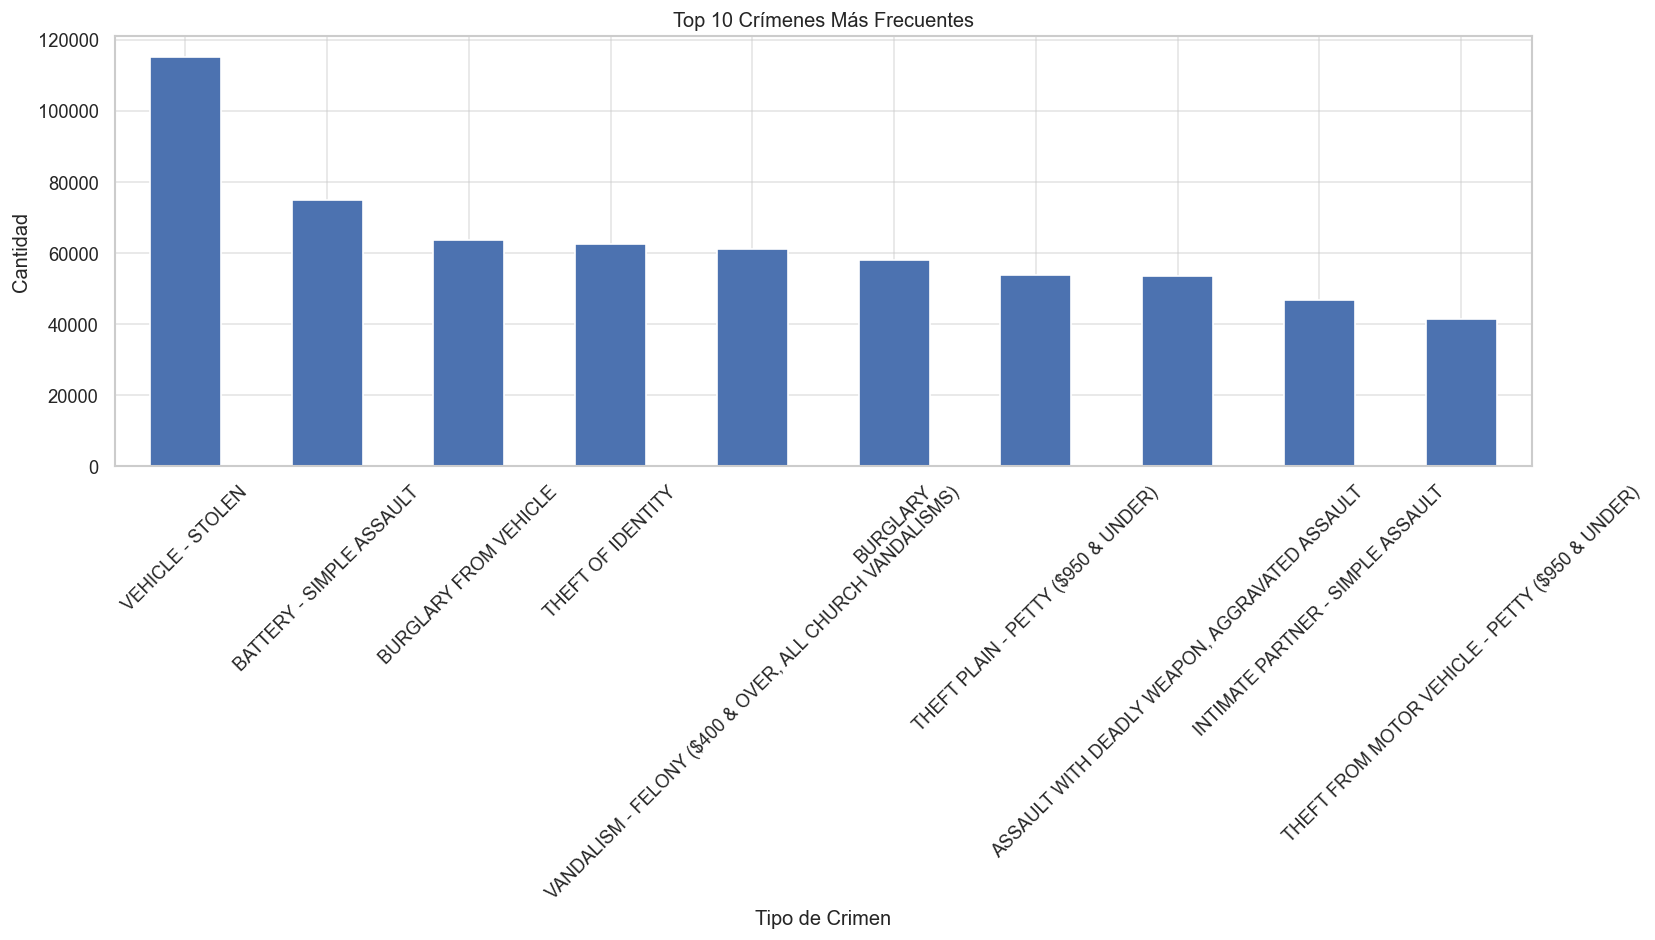

In [42]:
plt.figure(figsize=(14,8))

crime_df['Crm Cd Desc'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Crímenes Más Frecuentes')
plt.xlabel('Tipo de Crimen')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../Jupyter/top_10_crimenes.png')

plt.show()

## Zonas con Mayor Criminalidad

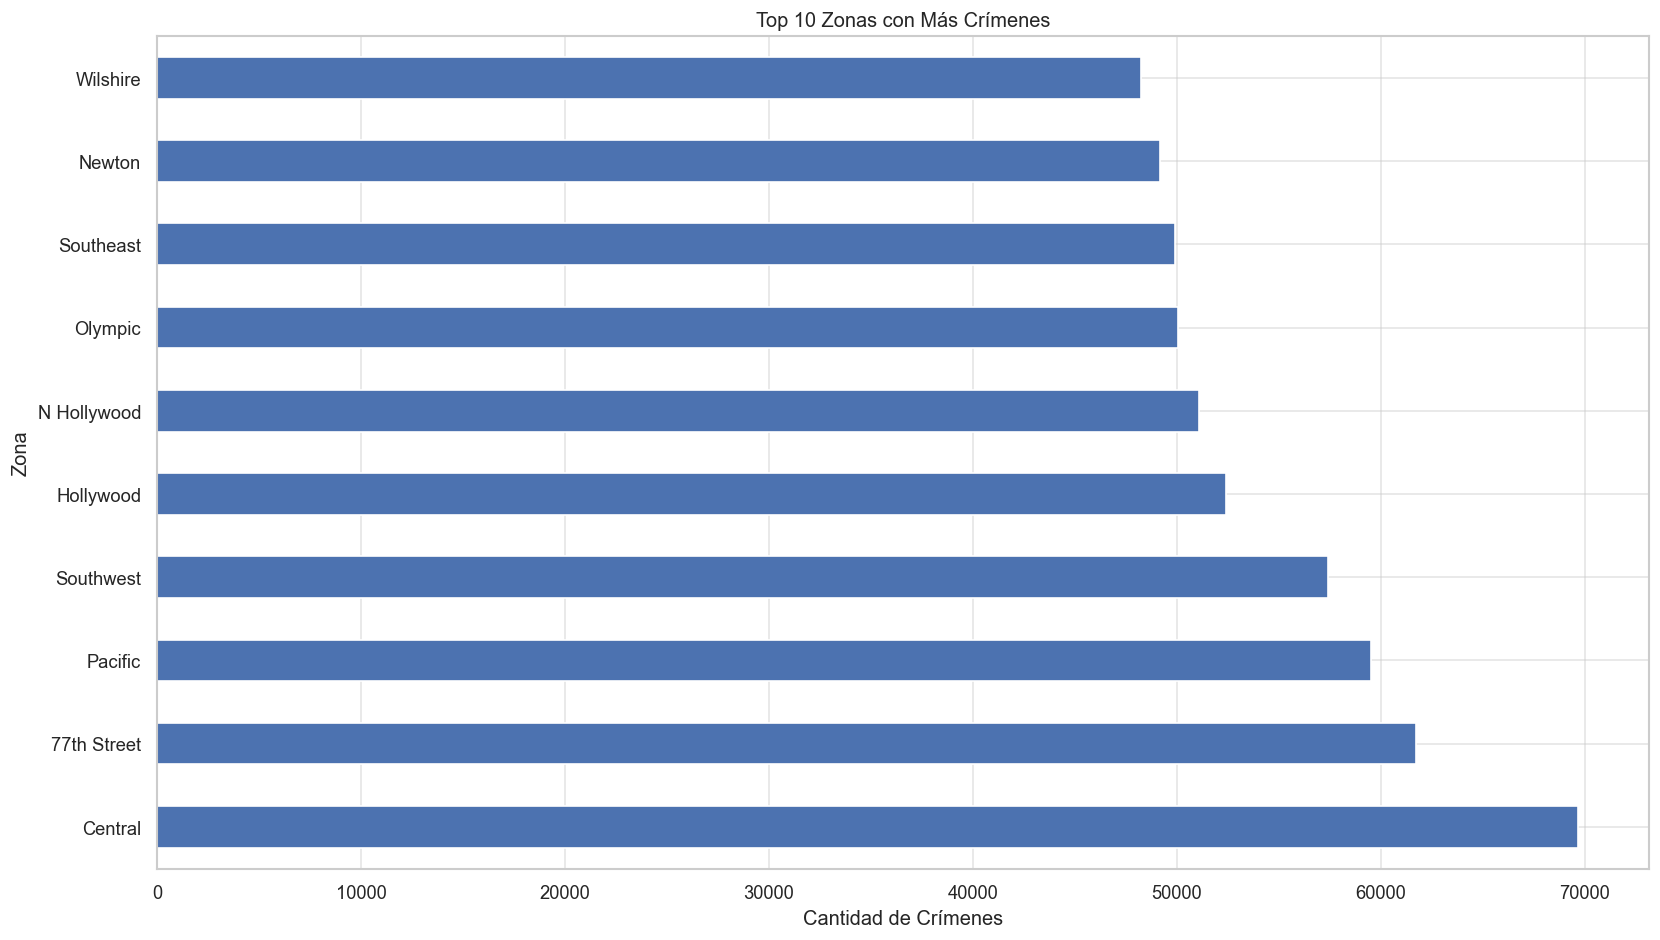

In [43]:
plt.figure(figsize=(14,8))

crime_df['AREA NAME'].value_counts().head(10).plot(kind='barh')

plt.title('Top 10 Zonas con Más Crímenes')
plt.xlabel('Cantidad de Crímenes')
plt.ylabel('Zona')

plt.tight_layout()

plt.savefig('../Jupyter/zonas_mas_crimenes.png')

plt.show()

## Evolución de Crímenes por Año

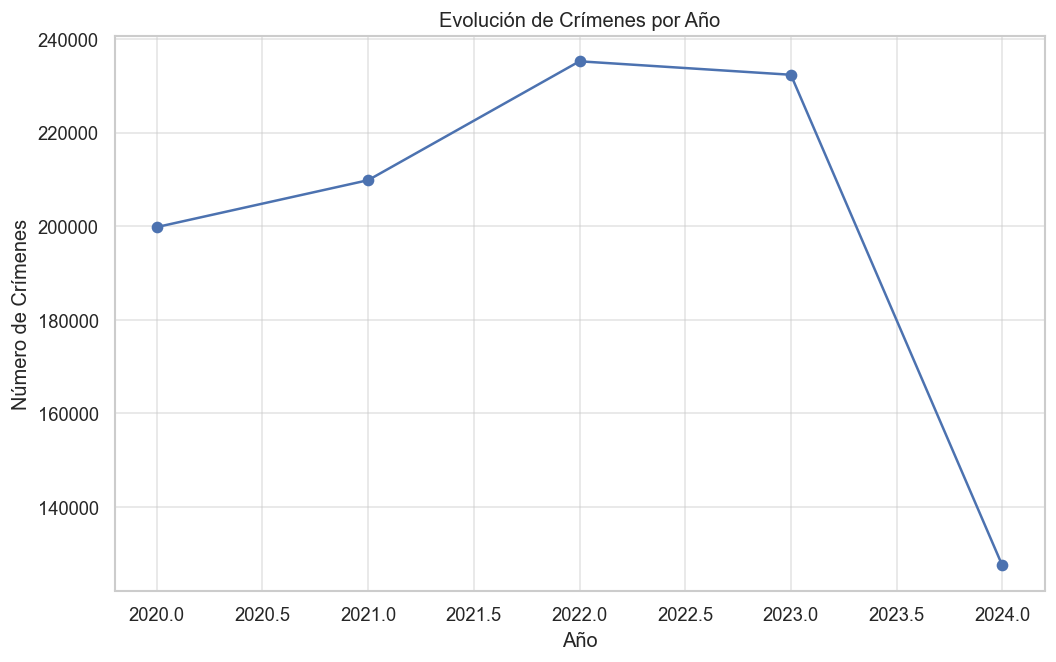

In [44]:
crimenes_por_anio = clean_df.groupby('YEAR_OCC').size()

plt.figure(figsize=(10,6))

crimenes_por_anio.plot(marker='o')

plt.title('Evolución de Crímenes por Año')
plt.xlabel('Año')
plt.ylabel('Número de Crímenes')

plt.savefig('../Jupyter/crimenes_por_anio.png')

plt.show()

## GroupBy

In [45]:
promedio_edad_por_zona = clean_df.groupby('AREA NAME')['Vict Age'].mean().sort_values(ascending=False)

print(promedio_edad_por_zona.head(10))

AREA NAME
West LA        41.376403
West Valley    41.053848
Devonshire     40.856640
Topanga        40.638298
Van Nuys       40.077903
Pacific        39.863629
Northeast      39.761241
Foothill       39.496181
Harbor         39.412664
N Hollywood    39.348734
Name: Vict Age, dtype: float64


# ==============================================
# 2. PATRONES DE DISTRIBUCIÓN
# ==============================================

## Histograma de Edad de Víctimas

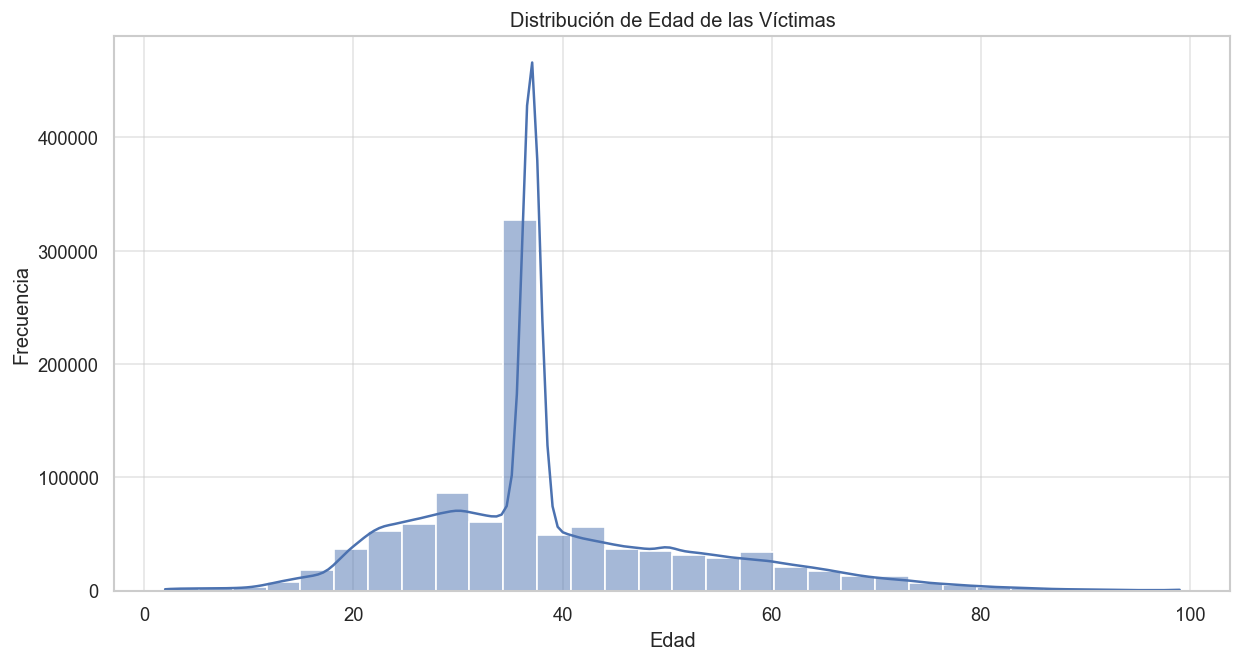

In [46]:
plt.figure(figsize=(12,6))

sns.histplot(clean_df['Vict Age'], bins=30, kde=True)

plt.title('Distribución de Edad de las Víctimas')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.savefig('../Jupyter/histograma_edades.png')

plt.show()

## Boxplot de Edad

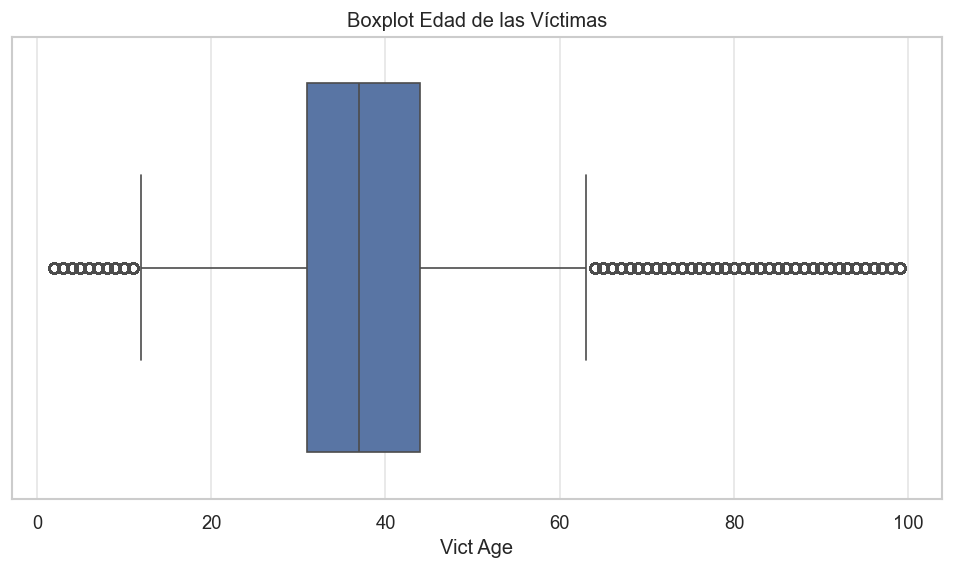

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(x=clean_df['Vict Age'])

plt.title('Boxplot Edad de las Víctimas')

plt.savefig('../Jupyter/boxplot_edades.png')

plt.show()

## Distribución por Sexo

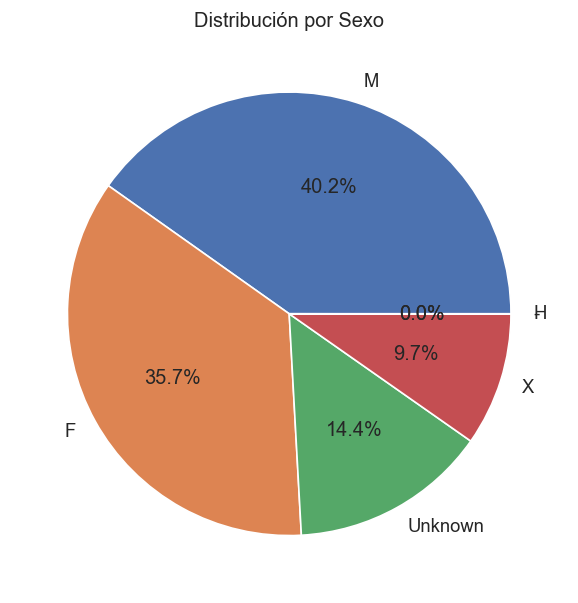

In [48]:
plt.figure(figsize=(8,6))

clean_df['Vict Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Distribución por Sexo')
plt.ylabel('')

plt.savefig('../Jupyter/distribucion_sexo.png')

plt.show()

# ==============================================
# 3. RELACIÓN ENTRE VARIABLES
# ==============================================

## Matriz de Correlación

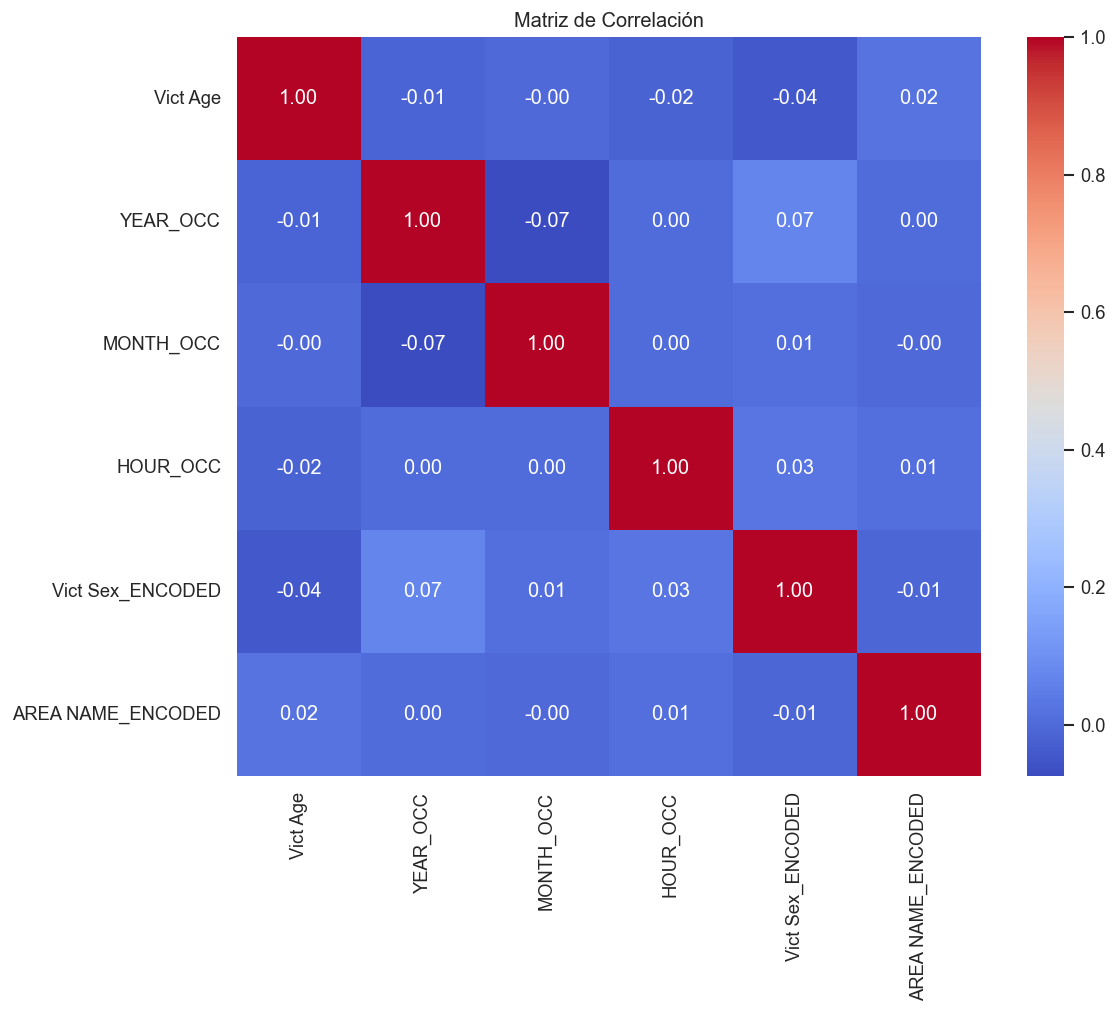

In [49]:
correlation_columns = [
    'Vict Age',
    'YEAR_OCC',
    'MONTH_OCC',
    'HOUR_OCC',
    'Vict Sex_ENCODED',
    'AREA NAME_ENCODED'
]

correlation_matrix = clean_df[correlation_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Matriz de Correlación')

plt.savefig('../Jupyter/heatmap_correlacion.png')

plt.show()

# ==============================================
# 4. ANÁLISIS TEMPORAL
# ==============================================

## Crímenes por Mes

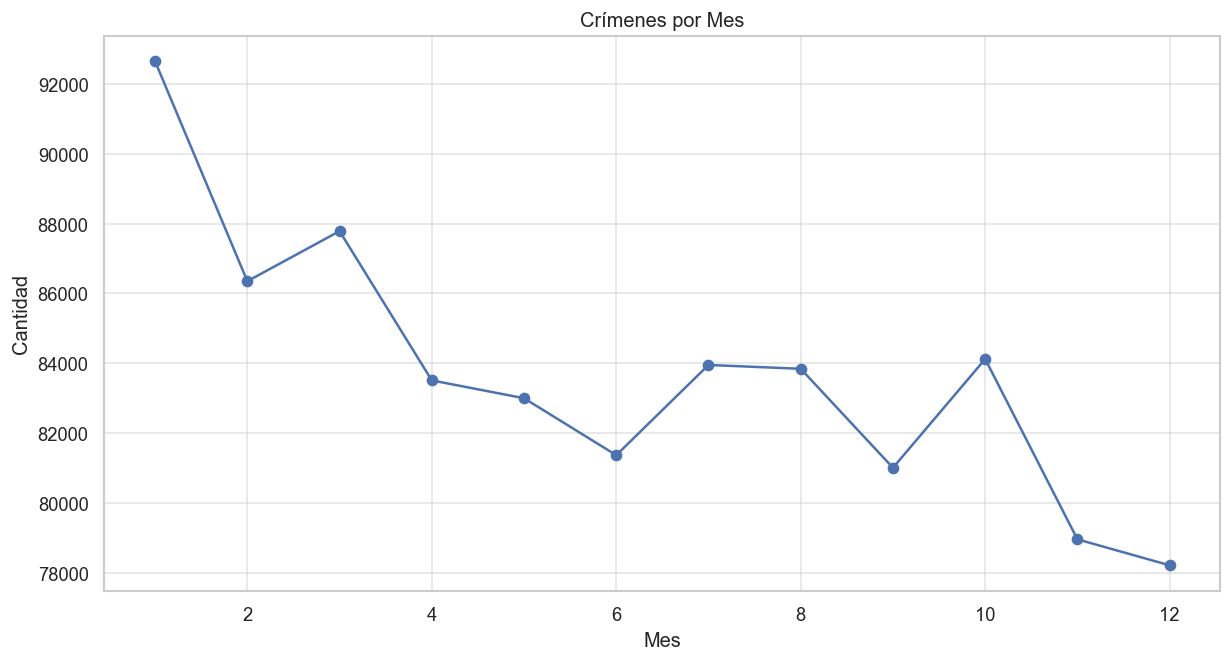

In [50]:
plt.figure(figsize=(12,6))

clean_df['MONTH_OCC'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title('Crímenes por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')

plt.savefig('../Jupyter/crimenes_por_mes.png')

plt.show()

# ==============================================
# 5. ANÁLISIS AVANZADO
# ==============================================

## Top 15 Armas Utilizadas

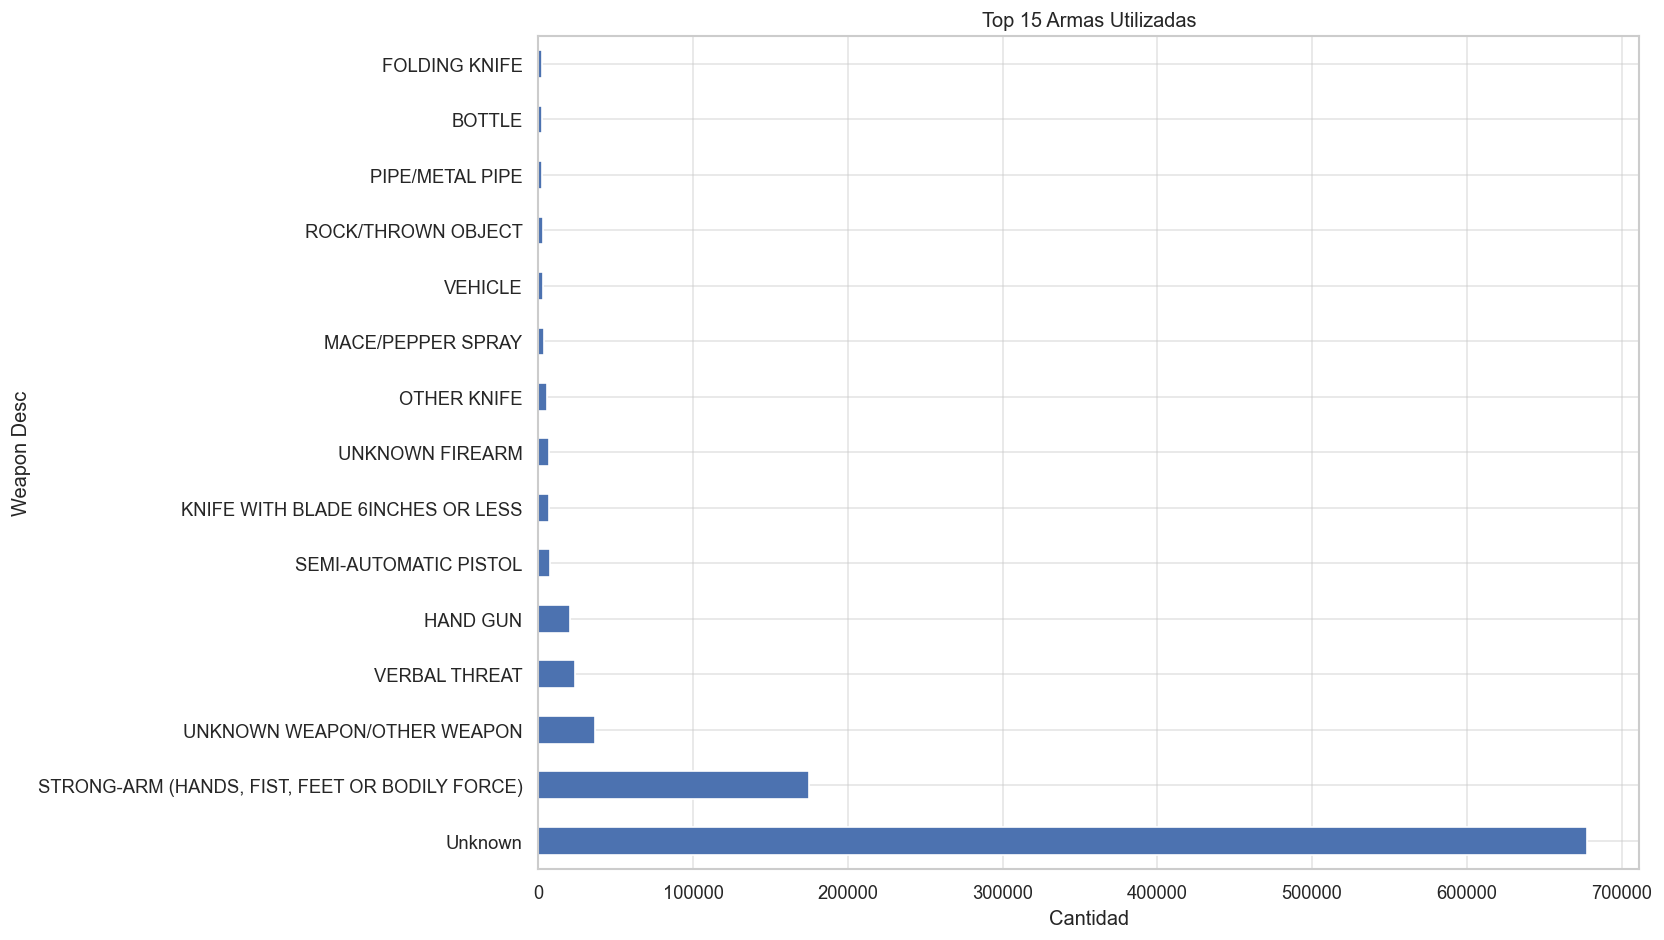

In [51]:
plt.figure(figsize=(14,8))

clean_df['Weapon Desc'].value_counts().head(15).plot(kind='barh')

plt.title('Top 15 Armas Utilizadas')
plt.xlabel('Cantidad')

plt.tight_layout()

plt.savefig('../Jupyter/top_armas.png')

plt.show()

# ==============================================
# CONCLUSIONES DEL NEGOCIO
# ==============================================

## Conclusiones

1. Algunos tipos de delitos aparecen con mucha más frecuencia que otros.

2. Existen zonas concretas con índices de criminalidad significativamente superiores.

3. La mayoría de víctimas se concentran en determinados rangos de edad.

4. Las horas nocturnas presentan mayor volumen de delitos.

5. La matriz de correlación muestra relaciones débiles entre las variables numéricas, lo que indica que la criminalidad depende de múltiples factores.

6. Se detectaron valores atípicos y datos incompletos que fueron tratados mediante limpieza y estandarización.


---

# ==============================================
# EXPORTACIÓN FINAL DEL DATASET LIMPIO
# ==============================================

In [52]:
clean_df.to_csv('../Files/crime_data_cleaned.csv', index=False)

print('Dataset limpio exportado correctamente')

Dataset limpio exportado correctamente
